# Phân cụm bằng Fuzzy C-Means

Gồm 4 phần chính:

1. Đọc và tiền xử lý dữ liệu (dùng chung công thức với notebook K-Means để 2 kết quả so sánh được trên cùng 1 không gian dữ liệu)
2. Cài đặt thuật toán Fuzzy C-Means (FCM)
3. Khảo sát sai số theo số cụm k
4. Chạy FCM với k đã chọn, trích xuất nhãn cứng + độ chắc chắn, và trực quan hóa

## Bước 1: Đọc và tiền xử lý dữ liệu

Giống cách tiền xử lý ở notebook K-Means (loại NaN ở 3 cột `orbital_period`, `mass`, `distance`, lấy `log10` rồi `StandardScaler`) — dùng chung 1 công thức tiền xử lý để 2 thuật toán được so sánh công bằng trên cùng 1 tập dữ liệu đầu vào `X`.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from IPython.display import display

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

PROJECT_DIR = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "data" / "Sampledata" / "planets.csv").exists()
)
DATA_PATH = PROJECT_DIR / "data" / "Sampledata" / "planets.csv"

df = pd.read_csv(DATA_PATH)
sub = df.dropna(subset=["orbital_period", "mass", "distance"]).copy().reset_index(drop=True)
feat_log = pd.DataFrame({
    "log_orbital_period": np.log10(sub["orbital_period"]),
    "log_mass": np.log10(sub["mass"]),
    "log_distance": np.log10(sub["distance"]),
})
X = StandardScaler().fit_transform(feat_log)
print(f"Đọc dữ liệu từ: {DATA_PATH}")
print(f"Số dòng dùng để phân cụm: {len(sub)} / {len(df)}")

Đọc dữ liệu từ: d:\ml-ai\PCT\data\Sampledata\planets.csv
Số dòng dùng để phân cụm: 498 / 1035


## Bước 2: Cài đặt thuật toán Fuzzy C-Means (FCM)

Khác với K-Means (mỗi điểm chỉ thuộc đúng 1 cụm), FCM cho phép mỗi điểm có **độ thuộc (membership)** vào tất cả các cụm — là số thực từ 0 đến 1, tổng độ thuộc của 1 điểm vào tất cả các cụm luôn bằng 1.

4 hàm tương ứng 4 bước của thuật toán:
- `initialize_centroids`: khởi tạo tâm cụm ngẫu nhiên, lấy min/max **theo từng cột** (không gộp chung toàn bộ dataset) — quan trọng vì các cột dữ liệu có thang đo khác nhau, nếu lấy min/max chung dễ đặt tâm cụm ở vị trí phi thực tế cho một số chiều.
- `update_membership`: cập nhật độ thuộc — điểm càng gần tâm cụm nào thì độ thuộc vào cụm đó càng cao, theo đúng công thức chuẩn của Bezdek.
- `update_centroids`: cập nhật tâm cụm mới — là trung bình có trọng số, trọng số là độ thuộc lũy thừa `m` (tham số làm mờ, ở đây `m=2`).
- `calculate_error`: tính hàm mục tiêu (tổng khoảng cách bình phương có trọng số) — dùng để theo dõi mức độ hội tụ.
- `fuzzy_cmeans`: hàm tổng hợp, lặp lại `update_membership` → `update_centroids` → `calculate_error` đúng `num_iterations` lần.

In [2]:
def initialize_centroids(dataset, k, rng):
    mins = dataset.min(axis=0)
    maxs = dataset.max(axis=0)
    return rng.uniform(mins, maxs, size=(k, dataset.shape[1]))


def update_membership(dataset, centroids, m, eps=1e-12):
    membership = np.empty((len(dataset), len(centroids)))
    exponent = 2 / (m - 1)
    for row, data in enumerate(dataset):
        distances = np.maximum(np.linalg.norm(data - centroids, axis=1), eps)
        membership[row] = 1 / np.sum((distances[:, None] / distances[None, :]) ** exponent, axis=1)
    return membership


def update_centroids(dataset, membership, m):
    weights = membership ** m
    return (weights.T @ dataset) / weights.sum(axis=0)[:, None]


def calculate_error(dataset, centroids, membership, m):
    distances_squared = np.linalg.norm(dataset[:, None, :] - centroids[None, :, :], axis=2) ** 2
    return np.sum((membership ** m) * distances_squared)


def fuzzy_cmeans(dataset, k, num_iterations, m, rng):
    centroids = initialize_centroids(dataset, k, rng)
    errors = []
    for _ in range(num_iterations):
        membership = update_membership(dataset, centroids, m)
        centroids = update_centroids(dataset, membership, m)
        errors.append(calculate_error(dataset, centroids, membership, m))
    return centroids, membership, errors

## Bước 3: Khảo sát sai số theo số cụm k

Khác với K-Means (có silhouette score để tự động chọn k), hàm sai số (`error`) của FCM sẽ **luôn giảm dần** khi k tăng (thêm cụm luôn làm giảm sai số nội tại), nên không có điểm "tối ưu" rõ ràng để máy tự chọn. Biểu đồ này chỉ để tham khảo xu hướng giảm dần, còn `K_CHOSEN = 4` được chọn thủ công — cố tình chọn trùng với k đã dùng ở notebook K-Means để 2 kết quả so sánh được với nhau.

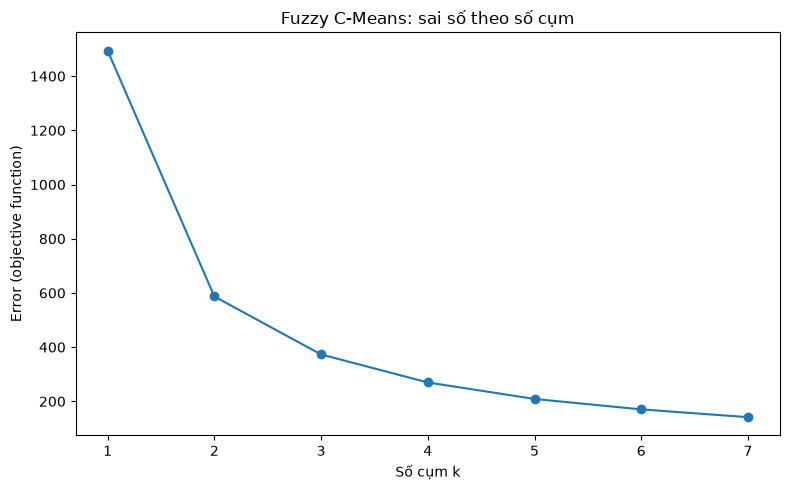

,k,error
0,1,1494.000000
1,2,586.914802
2,3,372.990566
3,4,269.728362
4,5,208.817191
5,6,170.369758
6,7,141.619954


In [3]:
K_range = range(1, 8)
fcm_errors = []
for k in K_range:
    _, _, errors = fuzzy_cmeans(X, k=k, num_iterations=100, m=2, rng=rng)
    fcm_errors.append(errors[-1])

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), fcm_errors, "o-")
plt.title("Fuzzy C-Means: sai số theo số cụm")
plt.xlabel("Số cụm k")
plt.ylabel("Error (objective function)")
plt.tight_layout()
plt.show()
display(pd.DataFrame({"k": list(K_range), "error": fcm_errors}))

K_CHOSEN = 4

## Bước 4: Chạy FCM với k đã chọn, trích xuất nhãn cứng và độ chắc chắn

- Chạy `fuzzy_cmeans()` với `k = K_CHOSEN`, thu được ma trận `membership` (mỗi hàng là 1 hành tinh, mỗi cột là độ thuộc vào 1 cụm).
- `hard_labels = argmax(membership)`: khi cần 1 nhãn cụ thể duy nhất cho mỗi điểm (để vẽ biểu đồ, xuất báo cáo...), ta chọn cụm có độ thuộc cao nhất làm "nhãn cứng".
- `max_membership`: giá trị độ thuộc cao nhất đó — coi như "độ tự tin" của máy khi gán nhãn (gần 1 = rất chắc chắn, gần 1/k = mơ hồ, khó phân biệt giữa các cụm).
- Bảng `result` cuối cùng liệt kê từng hành tinh kèm cụm được gán và độ tự tin tương ứng.

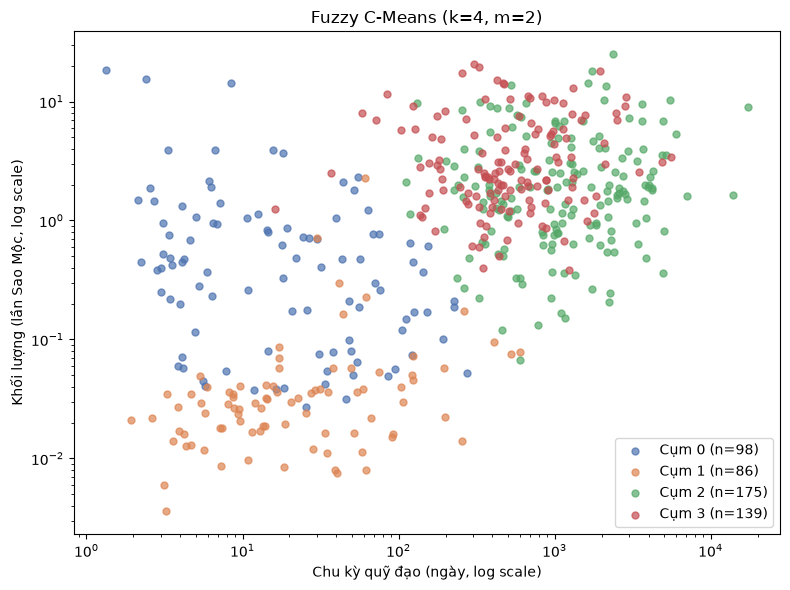

,method,number,orbital_period,mass,distance,year,fcm_cluster,fcm_max_membership
0,Radial Velocity,1,269.30000,7.100,77.40,2006,3,0.7778
1,Radial Velocity,1,874.77400,2.210,56.95,2008,3,0.6004
2,Radial Velocity,1,763.00000,2.600,19.84,2011,2,0.7949
3,Radial Velocity,1,326.03000,19.400,110.62,2007,3,0.6592
4,Radial Velocity,1,516.22000,10.500,119.47,2009,3,0.7547
...,...,...,...,...,...,...,...,...
493,Radial Velocity,1,111.70000,2.100,14.90,2009,2,0.4144
494,Radial Velocity,1,5.05050,1.068,44.46,2013,0,0.7036
495,Radial Velocity,1,311.28800,1.940,17.24,1999,2,0.6175
496,Transit,1,2.70339,1.470,178.00,2013,0,0.4109


Error cuối cùng: 269.7284


In [4]:
centroids_fcm, membership, errors = fuzzy_cmeans(
    X, k=K_CHOSEN, num_iterations=100, m=2, rng=rng
)
hard_labels = np.argmax(membership, axis=1)
max_membership = np.max(membership, axis=1)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]
plt.figure(figsize=(8, 6))
for cluster in range(K_CHOSEN):
    points = sub[hard_labels == cluster]
    plt.scatter(
        points["orbital_period"],
        points["mass"],
        s=25,
        alpha=0.7,
        color=colors[cluster % len(colors)],
        label=f"Cụm {cluster} (n={len(points)})",
    )
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Chu kỳ quỹ đạo (ngày, log scale)")
plt.ylabel("Khối lượng (lần Sao Mộc, log scale)")
plt.title(f"Fuzzy C-Means (k={K_CHOSEN}, m=2)")
plt.legend()
plt.tight_layout()
plt.show()

result = sub[["method", "number", "orbital_period", "mass", "distance", "year"]].copy()
result["fcm_cluster"] = hard_labels
result["fcm_max_membership"] = np.round(max_membership, 4)
display(result)
print(f"Error cuối cùng: {errors[-1]:.4f}")